In [1]:
# ==============================================================================
# 1. CORE DATA MANIPULATION & PATH UTILITIES
# ==============================================================================
import warnings
from pathlib import Path
import numpy as np
import pandas as pd

# Suppress unnecessary runtime warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 2. DATA VISUALIZATION & AESTHETICS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

# ==============================================================================
# 3. FEATURE PREPROCESSING & DATA SPLITTING
# ==============================================================================
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# ==============================================================================
# 4. CLASSIFICATION ALGORITHMS
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# ==============================================================================
# 5. EVALUATION METRICS (THE CLASSIFICATION SUITE)
# ==============================================================================
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)

# ==============================================================================
# 6. PIPELINE ORCHESTRATION & SERIALIZATION
# ==============================================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib

print("✅ Enterprise ML Libraries imported successfully.")


✅ Enterprise ML Libraries imported successfully.


In [2]:
data_path = Path("data/student_pass_fail_prediction/student-por-train.csv")

if not data_path.exists():
    raise FileNotFoundError(f"❌ File not found at: {data_path.resolve()}")

df = pd.read_csv(data_path)
print(f"Data Loaded! Shape: {df.shape}")


Data Loaded! Shape: (649, 32)


In [3]:
def senior_data_audit(df, target_col='target'):
    print("=" * 60)
    print("📋 SENIOR DEVELOPER DATA INGESTION AUDIT")
    print("=" * 60)
    
    # 1. Shape check
    print(f"1. Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    # 2. Duplicate check
    dups = df.duplicated().sum()
    print(f"2. Duplicate Rows: {dups:,} ({dups/len(df)*100:.2f}%)")
    
    # 3. Missing Values Summary
    total_nulls = df.isnull().sum().sum()
    print(f"3. Total Missing Values: {total_nulls:,}")
    if total_nulls > 0:
        null_cols = df.isnull().sum()[df.isnull().sum() > 0]
        print(f"   Columns with Nulls:\n{null_cols}")
        
    # 4. Target Variable Check
    if target_col in df.columns:
        print(f"\n4. Target '{target_col}' Class Counts:")
        print(df[target_col].value_counts(dropna=False))
        print("\n   Class Proportions (%):")
        print((df[target_col].value_counts(normalize=True, dropna=False) * 100).round(2))
    else:
        print(f"⚠️ Target column '{target_col}' not found in columns!")
        
    # 5. Data Types breakdown
    num_cols = df.select_dtypes(include=['number']).shape[1]
    cat_cols = df.select_dtypes(include=['object', 'category']).shape[1]
    print(f"\n5. Feature Types: {num_cols} Numerical, {cat_cols} Categorical")
    print("=" * 60)

# Run audit immediately after loading
senior_data_audit(df, target_col='pass')


📋 SENIOR DEVELOPER DATA INGESTION AUDIT
1. Dimensions: 649 rows × 32 columns
2. Duplicate Rows: 0 (0.00%)
3. Total Missing Values: 0

4. Target 'pass' Class Counts:
pass
1    549
0    100
Name: count, dtype: int64

   Class Proportions (%):
pass
1    84.59
0    15.41
Name: proportion, dtype: float64

5. Feature Types: 15 Numerical, 17 Categorical


In [4]:
# ==============================================================================
# STEP 2: DATA HYGIENE - D: DATA TYPES AUDIT & FEATURE SEGREGATION
# ==============================================================================

print("=" * 60)
print("🔍 SENIOR DATA TYPES AUDIT")
print("=" * 60)

# 1. Dtypes Breakdown
print()
print("1. Data Types Distribution:")
print(df.dtypes.value_counts())

# 2. Automated Feature Segregation via Domain Cardinality
CARDINALITY_THRESHOLD = 10
target_col = 'pass'

continuous_features = []
categorical_features = []

for col in df.columns:
    if col == target_col:
        continue
    n_unique = df[col].nunique(dropna=True)
    if df[col].dtype == 'object' or df[col].dtype.name == 'category' or n_unique <= CARDINALITY_THRESHOLD:
        categorical_features.append(col)
    else:
        continuous_features.append(col)

print()
print("2. Feature Segregation:")
print(f"   • Continuous Features  ({len(continuous_features)} cols) -> StandardScaler required:")
print(f"     {continuous_features}")
print(f"   • Categorical Features ({len(categorical_features)} cols) -> One-Hot / Label Encoding required:")
print(f"     {categorical_features}")
print(f"   • Target Feature: '{target_col}' (Dtype: {df[target_col].dtype})")

# 3. Target Sanity Check
assert set(df[target_col].unique()).issubset({0, 1}), "❌ Target must only contain 0 and 1!"
assert np.issubdtype(df[target_col].dtype, np.integer), "❌ Target dtype must be integer!"
print("   • Target Status: ✅ Perfectly binary & integer!")
print("=" * 60)


🔍 SENIOR DATA TYPES AUDIT

1. Data Types Distribution:
str      17
int64    15
Name: count, dtype: int64

2. Feature Segregation:
   • Continuous Features  (2 cols) -> StandardScaler required:
     ['absences', 'G3']
   • Categorical Features (29 cols) -> One-Hot / Label Encoding required:
     ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
   • Target Feature: 'pass' (Dtype: int64)
   • Target Status: ✅ Perfectly binary & integer!


In [5]:
# ==============================================================================
# STEP 3: DATA HYGIENE - D: MISSING VALUES AUDIT & TARGET CLEANING
# ==============================================================================

print("=" * 60)
print("🔍 SENIOR MISSING VALUES AUDIT")
print("=" * 60)

missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()
print(f"Total Missing Values in Dataset: {total_missing:,}")

if total_missing > 0:
    cols_with_nulls = missing_counts[missing_counts > 0]
    print()
    print("Columns with Missing Values:")
    for col, cnt in cols_with_nulls.items():
        pct = (cnt / len(df)) * 100
        print(f"  • {col:<20}: {cnt} missing ({pct:.2f}%)")
else:
    print("✅ No missing values found in the dataset! Dataset is 100% complete.")

# Target Null Check & Sanitization
if df[target_col].isnull().sum() > 0:
    initial_rows = len(df)
    df.dropna(subset=[target_col], inplace=True)
    print(f"⚠️ Dropped unlabelled target rows. Clean shape: {df.shape}")
else:
    print(f"✅ Target column '{target_col}' has zero missing values. Clean shape: {df.shape}")
print("=" * 60)


🔍 SENIOR MISSING VALUES AUDIT
Total Missing Values in Dataset: 0
✅ No missing values found in the dataset! Dataset is 100% complete.
✅ Target column 'pass' has zero missing values. Clean shape: (649, 32)


In [6]:
# ==============================================================================
# STEP 4: DATA HYGIENE - D: DUPLICATE RECORDS AUDIT & PURGING
# ==============================================================================

print("=" * 60)
print("🧹 SENIOR DEVELOPER DEDUPLICATION PROTOCOL")
print("=" * 60)

initial_rows = len(df)
dups = df.duplicated().sum()

if dups > 0:
    print(f"⚠️ Found {dups:,} duplicate records ({dups / initial_rows * 100:.2f}% of dataset).")
    df.drop_duplicates(keep='first', inplace=True)
    print(f"✅ Successfully removed {dups:,} duplicate records. Clean shape: {df.shape}")
else:
    print("✅ Zero duplicate records found. Dataset is already 100% free of duplicate leakage!")
print("=" * 60)

🧹 SENIOR DEVELOPER DEDUPLICATION PROTOCOL
✅ Zero duplicate records found. Dataset is already 100% free of duplicate leakage!


In [7]:
# ==============================================================================
# STEP 5: TARGET VARIABLE ANALYSIS & ZERO-RULE BASELINE BENCHMARK
# ==============================================================================
from sklearn.dummy import DummyClassifier

target_col = 'pass'

# 1. Feature Matrix (X) aur Target Vector (y) alag karo
X = df.drop(columns=[target_col])
y = df[target_col]

# 2. Dummy Classifier (Most frequent class guess karne wala)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X, y)

# 3. Baseline Accuracy Score nikaalo
baseline_acc = dummy.score(X, y) * 100

print("=" * 60)
print(f"📊 ZERO-RULE BASELINE ACCURACY: {baseline_acc:.2f}%")
print("=" * 60)
print("🎯 Target Class Distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2).to_dict())
print("-" * 60)
print(f"👉 Model Benchmark: Logistic Regression ko is {baseline_acc:.2f}% baseline score se behtar perform karna hoga!")
print("=" * 60)

📊 ZERO-RULE BASELINE ACCURACY: 84.59%
🎯 Target Class Distribution (%):
{1: 84.59, 0: 15.41}
------------------------------------------------------------
👉 Model Benchmark: Logistic Regression ko is 84.59% baseline score se behtar perform karna hoga!


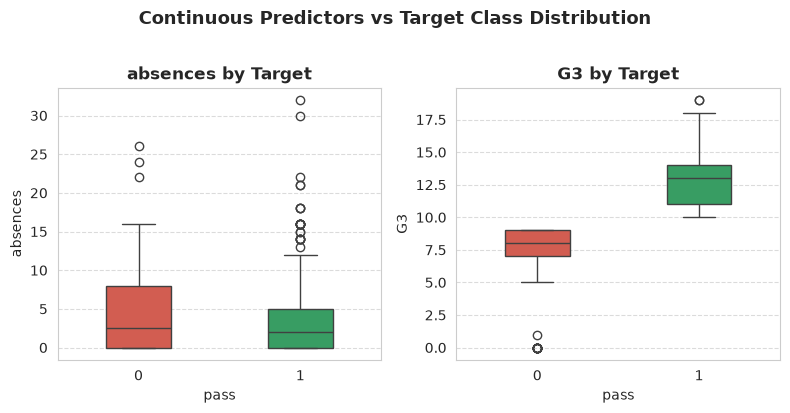

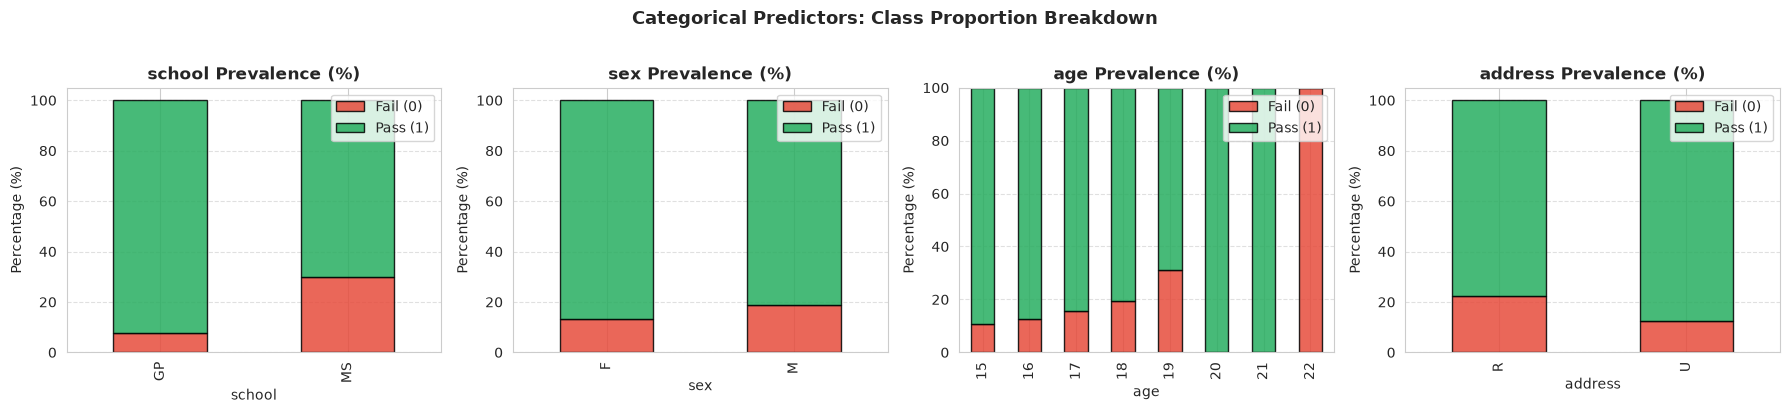

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def universal_classification_eda(df, target_col, max_num_cols=5, max_cat_cols=4):
    """
    Renders universal visual EDA for any classification dataset.
    """
    X = df.drop(columns=[target_col], errors='ignore')
    
    # Safe numerical check (Supports modern Pandas StringDtype without crashing)
    num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c]) and X[c].nunique() > 10][:max_num_cols]
    cat_cols = [c for c in X.columns if c not in num_cols][:max_cat_cols]
    
    # 1. Continuous Boxplots
    if num_cols:
        fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4))
        if len(num_cols) == 1: axes = [axes]
        palette = ['#e74c3c', '#27ae60']
        for idx, col in enumerate(num_cols):
            sns.boxplot(data=df, x=target_col, y=col, hue=target_col, palette=palette, legend=False, ax=axes[idx], width=0.4)
            axes[idx].set_title(f"{col} by Target", fontweight='bold')
            axes[idx].grid(axis='y', linestyle='--', alpha=0.7)
        plt.suptitle("Continuous Predictors vs Target Class Distribution", fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        
    # 2. Categorical Stacked Bar Plots
    if cat_cols:
        fig, axes = plt.subplots(1, len(cat_cols), figsize=(4.5 * len(cat_cols), 4))
        if len(cat_cols) == 1: axes = [axes]
        for idx, col in enumerate(cat_cols):
            ct_norm = pd.crosstab(df[col], df[target_col], normalize='index') * 100
            ct_norm.plot(kind='bar', stacked=True, color=['#e74c3c', '#27ae60'], ax=axes[idx], edgecolor='black', alpha=0.85)
            axes[idx].set_title(f"{col} Prevalence (%)", fontweight='bold')
            axes[idx].set_ylabel("Percentage (%)")
            axes[idx].legend(['Fail (0)', 'Pass (1)'], loc='upper right')
            axes[idx].grid(axis='y', linestyle='--', alpha=0.6)
        plt.suptitle("Categorical Predictors: Class Proportion Breakdown", fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

# Run EDA
universal_classification_eda(df, target_col='pass')

In [9]:
# ==============================================================================
# STEP 7: STRATIFIED TRAIN-TEST SPLIT (ZERO DATA LEAKAGE)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Feature Matrix (X) aur Target Vector (y) ko separate karo
target_col = 'pass'  # Apne target column ka naam yahan likhein

X = df.drop(columns=[target_col])
y = df[target_col]

# 2. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,       # 20% data testing (exam) ke liye alag rakhein
    random_state=42,      # Reproducibility ke liye seed
    stratify=y            # NON-NEGOTIABLE: Class proportions lock karta hai
)

# 3. Shapes Summary Print karo
print("=" * 60)
print("📦 STRATIFIED TRAIN-TEST SPLIT SUMMARY")
print("=" * 60)
print(f"Original Data Shape : {df.shape}")
print(f"X_train Shape       : {X_train.shape} (80% learning data)")
print(f"X_test Shape        : {X_test.shape}  (20% unseen test data)")
print(f"y_train Shape       : {y_train.shape}")
print(f"y_test Shape        : {y_test.shape}")

# 4. Stratification Sanity Check (Verification)
train_balance = (y_train.value_counts(normalize=True) * 100).round(2).to_dict()
test_balance  = (y_test.value_counts(normalize=True) * 100).round(2).to_dict()

print("-" * 60)
print("🎯 Class Distribution Balance Verification:")
print(f"Train Set Balance (%) : {train_balance}")
print(f"Test Set Balance (%)  : {test_balance}")
print("=" * 60)


📦 STRATIFIED TRAIN-TEST SPLIT SUMMARY
Original Data Shape : (649, 32)
X_train Shape       : (519, 31) (80% learning data)
X_test Shape        : (130, 31)  (20% unseen test data)
y_train Shape       : (519,)
y_test Shape        : (130,)
------------------------------------------------------------
🎯 Class Distribution Balance Verification:
Train Set Balance (%) : {1: 84.59, 0: 15.41}
Test Set Balance (%)  : {1: 84.62, 0: 15.38}


In [10]:
# ==============================================================================
# STEP 8: FEATURE PREPROCESSING (SCALING & ENCODING - ZERO LEAKAGE)
# ==============================================================================
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# 1. Continuous Features -> StandardScaler (Fit on Train, Transform on Test)
scaler = StandardScaler()
X_train_cont_scaled = scaler.fit_transform(X_train[continuous_features])
X_test_cont_scaled  = scaler.transform(X_test[continuous_features])

# 2. Categorical Features -> OneHotEncoder (drop='first' to prevent dummy trap)
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_cat_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_cat_encoded  = encoder.transform(X_test[categorical_features])

# 3. Horizontal Stacking (Combine continuous + categorical matrices)
X_train_final = np.hstack([X_train_cont_scaled, X_train_cat_encoded])
X_test_final  = np.hstack([X_test_cont_scaled,  X_test_cat_encoded])

print("=" * 60)
print("⚙️ STEP 8: FEATURE PREPROCESSING SUMMARY")
print("=" * 60)
print(f"Continuous Features Scaled  : {len(continuous_features)} cols -> Shape: {X_train_cont_scaled.shape}")
print(f"Categorical Features Encoded: {len(categorical_features)} cols -> Shape: {X_train_cat_encoded.shape}")
print(f"Final Training Matrix (X_train_final): {X_train_final.shape}")
print(f"Final Testing Matrix  (X_test_final) : {X_test_final.shape}")
print("=" * 60)


⚙️ STEP 8: FEATURE PREPROCESSING SUMMARY
Continuous Features Scaled  : 2 cols -> Shape: (519, 2)
Categorical Features Encoded: 29 cols -> Shape: (519, 74)
Final Training Matrix (X_train_final): (519, 76)
Final Testing Matrix  (X_test_final) : (130, 76)


🏆 MODEL TRAINING & EVALUATION REPORT
Train Accuracy : 100.00%
Test Accuracy  : 96.92% (Baseline Benchmark: 84.59%)
ROC-AUC Score  : 98.59%
------------------------------------------------------------
📊 Classification Report (Test Set):
              precision    recall  f1-score   support

    Fail (0)       0.94      0.85      0.89        20
    Pass (1)       0.97      0.99      0.98       110

    accuracy                           0.97       130
   macro avg       0.96      0.92      0.94       130
weighted avg       0.97      0.97      0.97       130

------------------------------------------------------------
🎯 Confusion Matrix:
[[ 17   3]
 [  1 109]]


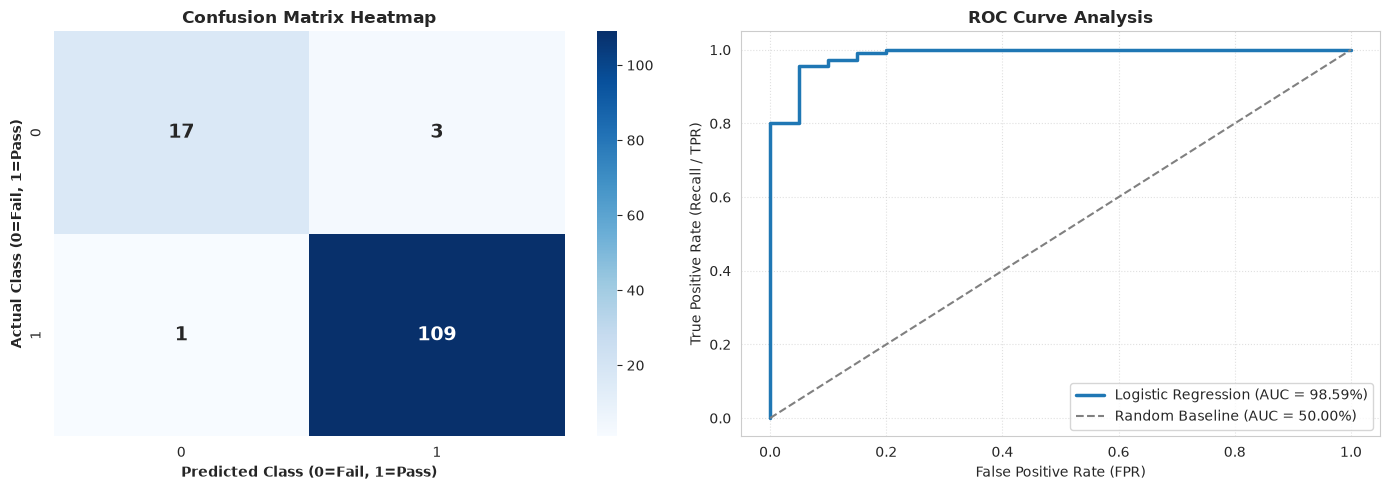

In [11]:
# ==============================================================================
# STEP 9 & 10: MODEL TRAINING & COMPREHENSIVE EVALUATION METRICS
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# 1. Train Logistic Regression Engine
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train_final, y_train)

# 2. Predictions (Hard Decisions vs Soft Probabilities)
y_train_pred = model.predict(X_train_final)
y_test_pred  = model.predict(X_test_final)
y_test_proba = model.predict_proba(X_test_final)[:, 1]

# 3. Performance Metrics
train_acc = accuracy_score(y_train, y_train_pred) * 100
test_acc  = accuracy_score(y_test, y_test_pred) * 100
test_auc  = roc_auc_score(y_test, y_test_proba) * 100
cm        = confusion_matrix(y_test, y_test_pred)

print("=" * 60)
print("🏆 MODEL TRAINING & EVALUATION REPORT")
print("=" * 60)
print(f"Train Accuracy : {train_acc:.2f}%")
print(f"Test Accuracy  : {test_acc:.2f}% (Baseline Benchmark: {baseline_acc:.2f}%)")
print(f"ROC-AUC Score  : {test_auc:.2f}%")
print("-" * 60)
print("📊 Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Fail (0)', 'Pass (1)']))
print("-" * 60)
print("🎯 Confusion Matrix:")
print(cm)
print("=" * 60)

# 4. Side-by-Side Diagnostic Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix Heatmap', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Class (0=Fail, 1=Pass)', fontweight='bold')
axes[0].set_ylabel('Actual Class (0=Fail, 1=Pass)', fontweight='bold')

# Plot B: ROC Curve Analysis
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AUC = {test_auc:.2f}%)')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Baseline (AUC = 50.00%)')
axes[1].set_title('ROC Curve Analysis', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (Recall / TPR)')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


🔍 TOP FACTORS DRIVING PASS / FAIL DECISIONS
🚀 Top 5 Factors that BOOST Pass Probability (w > 0):
 Feature  Weight_w  Odds_Ratio
      G3  5.772173  321.235152
 goout_3  0.606320    1.833671
health_2  0.502375    1.652642
  Medu_4  0.389244    1.475865
famrel_2  0.366810    1.443124

🛑 Top 5 Factors that PUSH Fail Risk (w < 0):
   Feature  Weight_w  Odds_Ratio
 school_MS -0.800111    0.449279
  paid_yes -0.393895    0.674425
    Fedu_1 -0.393806    0.674485
failures_3 -0.372309    0.689141
Fjob_other -0.361970    0.696303


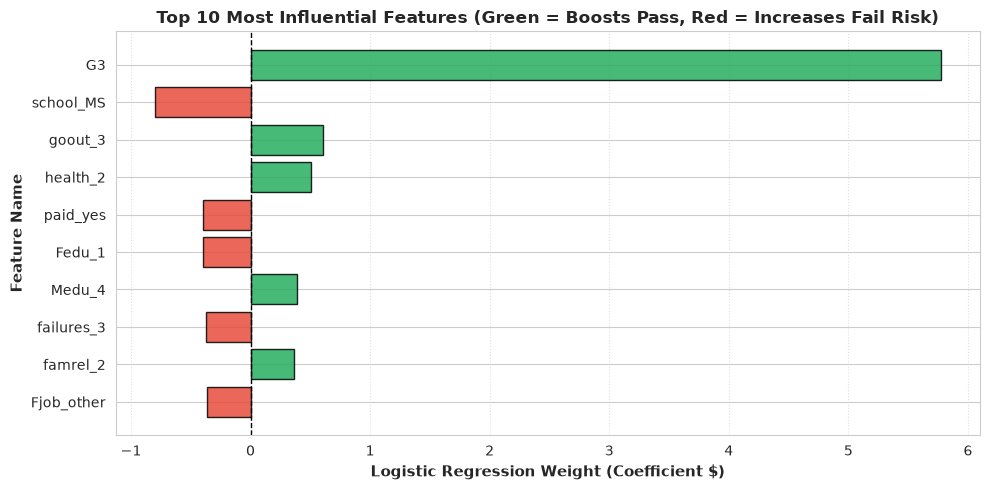

In [12]:
# ==============================================================================
# STEP 11: MODEL INTERPRETATION & FEATURE IMPORTANCE (ODDS RATIOS)
# ==============================================================================

# 1. Map all Feature Names (Continuous + Categorical Dummies)
cat_feature_names = list(encoder.get_feature_names_out(categorical_features))
all_feature_names = continuous_features + cat_feature_names

# 2. DataFrame: Weights & Odds Ratios (e^w)
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Weight_w': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
})
feature_importance_df['Abs_Impact'] = feature_importance_df['Weight_w'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Impact', ascending=False).reset_index(drop=True)

# 3. Print Top 5 Boosters and Top 5 Pushers
print("=" * 65)
print("🔍 TOP FACTORS DRIVING PASS / FAIL DECISIONS")
print("=" * 65)
print("🚀 Top 5 Factors that BOOST Pass Probability (w > 0):")
print(feature_importance_df.sort_values(by='Weight_w', ascending=False).head(5)[['Feature', 'Weight_w', 'Odds_Ratio']].to_string(index=False))

print()
print("🛑 Top 5 Factors that PUSH Fail Risk (w < 0):")
print(feature_importance_df.sort_values(by='Weight_w', ascending=True).head(5)[['Feature', 'Weight_w', 'Odds_Ratio']].to_string(index=False))
print("=" * 65)

# 4. Top 10 Most Decisive Features Horizontal Bar Chart
top_10 = feature_importance_df.head(10).sort_values(by='Abs_Impact', ascending=True)

plt.figure(figsize=(10, 5))
colors = ['#27ae60' if w > 0 else '#e74c3c' for w in top_10['Weight_w']]
plt.barh(top_10['Feature'], top_10['Weight_w'], color=colors, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Top 10 Most Influential Features (Green = Boosts Pass, Red = Increases Fail Risk)", fontsize=12, fontweight='bold')
plt.xlabel("Logistic Regression Weight (Coefficient $)", fontsize=11, fontweight='bold')
plt.ylabel("Feature Name", fontsize=11, fontweight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [13]:
# ==============================================================================
# STEP 12: ENTERPRISE PRODUCTION PIPELINE & MODEL SERIALIZATION
# ==============================================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import joblib
from pathlib import Path

# 1. Define ColumnTransformer Branches
continuous_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', continuous_pipeline, continuous_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

# 2. Master End-to-End Pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])

# 3. Single Fit on Raw Training Data (Zero Leakage Guaranteed!)
full_pipeline.fit(X_train, y_train)
pipeline_test_acc = full_pipeline.score(X_test, y_test) * 100

print("=" * 65)
print("🏭 ENTERPRISE PRODUCTION PIPELINE SUMMARY")
print("=" * 65)
print(f"End-to-End Pipeline Test Accuracy: {pipeline_test_acc:.2f}%")

# 4. Serialize Master Artifact (.joblib)
model_path = Path("production_models/student_pass_fail_pipeline.joblib")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(full_pipeline, model_path)
print(f"✅ Serialized Pipeline Bundle saved to: {model_path}")

# 5. Live Production Inference Smoke Test
loaded_pipeline = joblib.load(model_path)
sample_student = X_test.iloc[0:1]
pred_prob = loaded_pipeline.predict_proba(sample_student)[0, 1]
pred_class = loaded_pipeline.predict(sample_student)[0]

print()
print("🧪 Live Production Inference Test (1 Raw Sample):")
print(f"   • Predicted Class    : {'PASS (1)' if pred_class == 1 else 'FAIL (0)'}")
print(f"   • Pass Probability   : {pred_prob * 100:.2f}%")
print(f"   • Actual Ground Truth: {y_test.iloc[0]}")
print("=" * 65)


🏭 ENTERPRISE PRODUCTION PIPELINE SUMMARY
End-to-End Pipeline Test Accuracy: 96.92%
✅ Serialized Pipeline Bundle saved to: production_models/student_pass_fail_pipeline.joblib

🧪 Live Production Inference Test (1 Raw Sample):
   • Predicted Class    : PASS (1)
   • Pass Probability   : 97.49%
   • Actual Ground Truth: 1
